# Project: Long-term Evolution of Planetary System in a Star Cluster

In part 1, this notebook sets up a star cluster; in part 2, it sets up a planetary system.

Notes:
- This project is based on [this](https://academic.oup.com/mnras/article/470/4/4337/3867314) publication.
- The code starts up the built-in REBOUND [visualization web-server](https://rebound.hanno-rein.de/visualization/) with `sim.start_server(port=1234)`. If you go to http://localhost:1234 in your browser, you should see an animation of the particles as the simulation runs, together with some useful information such as the number of steps per second. Press 'h' on this screen to see a list of keyboard commands.
- Because we have many particles, the forces are calculated using a tree code (`sim.gravity = "tree"`) in which far away particles are grouped together for the purposes of calculating the gravitational force. This improves how the simulation time scales with number of particles from $\propto N^2$ to $\propto N\log N$ which gives a big speed up. 
- Due to last point, the notebook also provide an alternative C version of the code (in link), in which, it utilizes the built-in function of REBOUND, `reb_simulation_add_plummer(r, _N, M, R)` to set up a plummer sphere similarly.
- The tree code requires us to define a `boxsize` for the simulation. We use `'open'` boundary conditions, so that particles that leave the box are removed. If you look in the top left of the visualization window you will see that the total number of particles drops slightly over time as particles leave the simulation box.
- We also set a softening length (`sim.softening = 0.001*r0`, or in C, `r->softening = 0.001*r0`,r and sim are the variables of simulation) which softens the gravitational force at small separations (the interparticle potential is $\propto 1/\sqrt{r^2+\epsilon^2}$ rather than $\propto 1/r$). This avoids numerical errors that arise when two particles pass very close to one another and experience very large accelerations.

In [1]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from   matplotlib.gridspec import GridSpec
import rebound
import time
import numpy as np
import random


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top']       = True
plt.rcParams['ytick.right']     = True

## Part 1.1 Simulation of star Cluster

- The initial conditions for the simulation are
- Plummer distribution
- Virial equilibrium with radius 1 parsec
- Each star 0.5 solar masses



Here, in the following cell, the example is a cluster system with 1000 particles. The simulation will take a few minutes or more depending on the computing power. A typical star cluster can contain more stars than 1000, in the above mentioned publications, this number is 8000 to 32000. Such simulations can take more than 10 core-days. Using C version and MPI function of REBOUND is encouraged.

For that reason, there's no output here yet. 

In [ ]:
def setup_plummer_sphere(N, M_tot, R, 
                         name=False, specific = False, specific_names = None):
    # N: number of particles, M_tot: total mass, R, radius of sphere 
    
    # Algorithm from:	
    # http://adsabs.harvard.edu/abs/1974A%26A....37..183A

    # total energy
    E = 3./64.*np.pi*M_tot*M_tot/R*sim.G

    for i in range(N):
        # sample the coordinates
        r = (np.random.uniform(0,1)**(-2/3) - 1)**(-1/2)
        x2 = np.random.uniform(0,1)
        x3 = np.random.uniform(0,2*np.pi)
        
        z0 = (1.-2.*x2)*r;
        x0 = np.sqrt(r**2-z0**2)*np.cos(x3)
        y0 = np.sqrt(r**2-z0**2)*np.sin(x3)
 

        # choose velocity, so that the limit is escape velocity
        ve = np.sqrt(2)*(1.0+ r**2)**(-1./4.) # escape velocity

        while True:
            x5 = np.random.uniform(0,1)
            q  = np.random.uniform(0,1)
            g  = q**2*(1.-q**2)**(7./2.)
            if 0.1 * x5 <= g:
                break
        
        v = q*ve
        x6 = np.random.uniform(0,1)
        x7 = np.random.uniform(0,2*np.pi)

        vz0 = (1.-2.*x6)*v
        vx0 = np.sqrt(v**2 - vz0**2)*np.cos(x7)
        vy0 = np.sqrt(v**2 - vz0**2)*np.sin(x7)

        # add the particle, if naming is True, the Hash tag is the number order
        if name == True:
            sim.add(
                m  = M_tot/N,
                x  = x0*R, y  = y0*R, z  = z0*R,
                vx = vx0 * np.sqrt(E*64./3./np.pi/M_tot),
                vy = vy0 * np.sqrt(E*64./3./np.pi/M_tot),
                vz = vz0 * np.sqrt(E*64./3./np.pi/M_tot),
                hash = f"{i}"
            )
        elif specific == True:
            # specific naming only works when N = len(specific_names)            
            sim.add(
                m  = M_tot/N,
                x  = x0*R, y  = y0*R, z  = z0*R,
                vx = vx0 * np.sqrt(E*64./3./np.pi/M_tot),
                vy = vy0 * np.sqrt(E*64./3./np.pi/M_tot),
                vz = vz0 * np.sqrt(E*64./3./np.pi/M_tot),
                hash = f"{specific_names[i]}"
            ) 
        else:            
            sim.add(
                m  = M_tot/N,
                x  = x0*R, y  = y0*R, z  = z0*R,
                vx = vx0 * np.sqrt(E*64./3./np.pi/M_tot),
                vy = vy0 * np.sqrt(E*64./3./np.pi/M_tot),
                vz = vz0 * np.sqrt(E*64./3./np.pi/M_tot),
            )
    return

In [ ]:
start = time.time()

sim = rebound.Simulation()
# start the visualization server: in your browser go to http://localhost:3274
sim.start_server(port=3274)


# Setup system characteristics
_N     = 1000                     # Number of particles
parsec = 180.*3600./np.pi         # 1pc = 180*3600/pi AU
G      = 4*np.pi**2               # Gravitational constant, in AU^3 / MO / yr^2
M      = 0.5*_N                   # Total mass of the cluster, in solar masses, MO
R      = 3*np.pi/16*parsec        # Radius of the cluster, in AU
epi    = 3/64*np.pi*M*M/R*G       # Energy of the cluster
r0     = 1*parsec                 # Virial radius, 1pc
t0     = G*M**(5/2)*(4*epi)**(-3/2)*_N/np.log(0.4*_N)  #Rellaxation time
print("Characteristic size (pc):  %f\n", r0/parsec)
print("Relaxation time (Myrs):    %f\n", t0/1e6)


# set the gravity in our unit and the softening parameter to be 0.001 parsec
sim.G          = G
sim.softening  = 0.001*r0

# Option 1: use leapfrog (faster, not accurate for large dt) 
sim.integrator = "leapfrog"
sim.dt         = 50.  # 50 yrs is about enough to resolve motion


# Option 2: use default IAS 15 (adaptive timesteps)
sim.integrator = "ias15"


# Option 3: use tree gravity (fastest, but order of particles is shuffled,
# turn on "name" in setup_plummer_sphere function to fix this)
sim.integrator = "leapfrog"
sim.dt         = 25. 
sim.gravity    = "tree"


# define a box size for the simulation 
boxsize        = 20.*r0
sim.configure_box(boxsize, 1, 1, 1); 
# sim.boundary   = "open"


# stars
setup_plummer_sphere(_N, M, R, name=True)

# # Optional, to add star of interest, give specific names
# # So you can follow these stars specificly
# # Note: NN = len(names) here 
# NN     = 3
# Mstr   = 1     # again, in solar mass
# namess = ["SOI01", "SOI02", "SOI03"]
# setup_plummer_sphere(NN, NN*Mstr, R, 
#                     specific = True, specific_names = namess)


# move to center of mass frame
sim.move_to_com()



# setup time list 
Noutputs = 10000
times    = np.linspace(0, 5e6, Noutputs)  # total 5Myrs
dt_save  = times[-1]/(Noutputs-1)


# data storage
xyz  =  np.zeros((Noutputs, _N, 3))

print("Running simulation:")
for i,t in enumerate(times):
    sim.integrate(t, exact_finish_time=1)

    # for j, p in enumerate(sim.particles):
    #     xyz[i][j] = [p.x, p.y, p.z]

    # if names are used:
    for k in range(_N):
        p = sim.particles[f"{k}"]
        xyz[i][k] = [p.x, p.y, p.z]


# shut down the visualization server; this will stop it complaining next time we run the simulation
sim.stop_server(port=3274)
print('\nSim time = %.3f s' % (time.time()-start,))

In [ ]:
# The above simulation might take time to run, better to save the data
reshape_xyz   = xyz.reshape(-1, 3)
data_interest = reshape_xyz.T

np.savetxt("data07.csv", data_interest, delimiter=",")
print("data saved")

## Part 1.2: Plot and Animate the Star Cluster

The following script makes a series of plots of the star cluster. The motion is projected onto the x-y plane. Figures need to be saved in a folder `"./png"`, which need to be created prior to excuting the code. And wrtie your own code to turn png files to animations.

In [ ]:
# load the data
filename = "data07.csv"
data = np.loadtxt(filename)
print(f"Original shape: {data.shape}")

Nparticles = _N

tot_len = data.shape[0] // Nparticles
print("steps:", tot_len)

reshape_data = np.reshape(data, (tot_len, Nparticles, 3))

In [ ]:
factoring = 1

tail_trace_x = np.ones(tot_len//factoring)*reshape_data[0][0,0]
tail_trace_y = np.ones(tot_len//factoring)*reshape_data[0][0,1]

grayscale_values = np.ones(800)
grayscale_array = np.tile(grayscale_values, (3, 1)).T 


for i in range(tot_len//factoring):

    fig, ax= plt.subplots(1, 2, figsize=(14, 6),  width_ratios=[1, 1])

    # graph 1 in units of parsec
    ax[0].set_xlim(-2, 2)
    ax[0].set_ylim(-2, 2)
    ax[0].set_xlabel("Parsec")
    # graph 2 in AU
    ax[1].set_xlim(-5000, 5000)
    ax[1].set_ylim(-5000, 5000)
    ax[1].set_xlabel("AU")


    # tracking the position and trajectary of the star of interset(SOI)
    centre_x = reshape_data[i][0,0]
    centre_y = reshape_data[i][0,1]
    centre_z = reshape_data[i][0,2]

    tail_trace_x[i] = reshape_data[i*factoring][0,0]
    tail_trace_y[i] = reshape_data[i*factoring][0,1]


    # calculate the grey scale of other stars according to the z distance
    # here a radius of 1000 AU or smaller is 1,1,1 RGB, pure black
    # and 2 pc is 0,0,0, pure white, scaling is linear
    # close encounter within 200 AU is marked red
    z_positions = reshape_data[i][:,0] - centre_z
    z_1000      = np.abs(z_positions)
    ind_gray    = np.where(z_1000 > 1000)
    ind_white   = np.where(z_1000 > 2*parsec)
    ind_close   = np.where(z_1000 < 200)


    gray_scalez            = grayscale_array.copy()
    gray_tiles             = np.tile(z_1000[ind_gray], (3, 1)).T 
    gray_scalez[ind_gray] -=  gray_tiles/ (2*parsec)
    gray_scalez[ind_white] = [0, 0, 0]
    gray_scalez[ind_close] = [1, 0, 0]


    # Again, plot 1 in pc, SOI blue
    ax[0].scatter(reshape_data[i*factoring][:,0] / parsec, 
               reshape_data[i*factoring][:,1] / parsec,
               s=2, alpha = 0.6, zorder = 1, color = "black")
    ax[0].plot(reshape_data[i*factoring][0,0] / parsec, 
               reshape_data[i*factoring][0,1] / parsec,
               'bo',ms=5, zorder =3)
    ax[0].plot(tail_trace_x / parsec, tail_trace_y / parsec, 
                'o', ms=2.5, color='blue', alpha = 0.1, zorder =2)

    
    ax[1].scatter(reshape_data[i][:,0] - centre_x, 
             reshape_data[i][:,1] - centre_y,
             s=5,
             color = np.round(gray_scalez, 2))
    ax[1].plot(0,0,'bo',ms=7)

    # red cricle 1000 AU, encounter range
    # black cirle 200 AU, outer most planet range
    circle1 = plt.Circle((0, 0), 1000, fill=False, linestyle='--', linewidth=1.5, color='red')
    circle2 = plt.Circle((0, 0), 200, fill=False, linestyle='solid', linewidth=0.8, color='black')
    ax[1].add_patch(circle1)
    ax[1].add_patch(circle2)

    if i==tot_len//factoring: # show the last plot
        plt.show()

    plt.savefig('png/plot%03d.png' % (i,))
    plt.close()

## Part 1.3: Detect Close Encounter

- The first code block choose a star of interest among the 2000 stars, and detect the close encounter event that within $R_H = 1000 AU$.
- The second part generates a cumulative histgram of stars location (distance to cluster core $R_{SC}$), and a plot of 2000 stars' location $R_{SC}$ as a function of time.
- On top of the REBOUND environment, Pandas package is needed for handling the larger data files. 
- In this section, a simulation of 2000 stars over 5Myrs was perfomed and saved to files.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# check for close encounters
def detect_close_obj(reshape_data, soi_ind: int, 
                     r_H:float =  2000, dt = 1e-3):
    tot_len  = np.shape(reshape_data)[0]
    time_encount = []
    obj_ind      = []
    enc_position = []
    for i in range(tot_len):
        # locate the SOI 
        centre_x = reshape_data[i][soi_ind,0]
        centre_y = reshape_data[i][soi_ind,1]
        centre_z = reshape_data[i][soi_ind,2]
        # calculate distance r 
        dis_x    = reshape_data[i][:,0] - centre_x
        dis_y    = reshape_data[i][:,1] - centre_y
        dis_z    = reshape_data[i][:,2] - centre_z
        dis_r    = np.sqrt(dis_x**2+dis_y**2+dis_z**2)

        v_x    = reshape_data[i][:,3] - reshape_data[i][soi_ind,3]
        v_y    = reshape_data[i][:,4] - reshape_data[i][soi_ind,4]
        v_z    = reshape_data[i][:,5] - reshape_data[i][soi_ind,5]
        
        pot_ind  =  np.where(dis_r < r_H)
        if pot_ind[0].size == 1:
            None
        else:
            time_encount.append(i*dt)
            encounters_ind = np.where(pot_ind[0] != soi_ind)
            c = pot_ind[0][encounters_ind[0]]
            enc_xyz = [dis_x[c][0], dis_y[c][0], dis_z[c][0], v_x[c][0], v_y[c][0], v_z[c][0]]
            # print(enc_xyz)
            enc_position.append(enc_xyz)
            obj_ind.append(c)
            
    print(np.array(enc_position).shape)
    return np.array(time_encount), np.array(obj_ind), np.array(enc_position)

tot_len    = 5000
Nparticles = 2000


# here I saved the simulation results form the previous part in this file name
# load your own data 
# Star with index of 210 is chosen because it is colse to the cluster center
# where encounter event happens more frequently
filename   = "output_data06_0.csv"
data       = pd.read_csv(filename, delimiter=",")


choice     = 210
reshape_data = np.reshape(data, (tot_len, Nparticles, 6))
time , obj, enc_pos = detect_close_obj(reshape_data, soi_ind=choice, r_H=1000)

np.savetxt(str(choice)+"_encounter.csv", np.array([time, np.squeeze(obj)]).T, delimiter=",")
np.savetxt(str(choice)+"_enc_pos.csv", enc_pos, delimiter=",")
print("Sample 1: Star " + str(choice))
print("Close encounter time(Myr):", time)
print("Object index", np.squeeze(obj))

(24, 6)
Sample 1: Star 210
Close encounter time(Myr): [0.957 0.958 0.959 0.96  1.944 1.945 1.946 1.947 1.992 1.993 2.537 2.538
 2.539 2.891 2.892 2.893 2.987 3.421 3.422 3.423 3.424 4.327 4.328 4.329]
Object index [1992 1992 1992 1992 1262 1262 1262 1262 1952 1952  212  212  212 1822
 1822 1822  739 1272 1272 1272 1272 1789 1789 1789]


In the follwoing cell, the first plot shows the distance to cluster center ($R_{sc}$) of each star. $R_{1/2}$ is the cluster radius where it encloses half of the total mass. The second plot shows the cumulative number of stars (normalized to 1) with $R_{sc}$ in log scale. A sample was drawn (star 210 as stated above) shown on the cumulative plot.

objects close to center of cluster
89
210
302
392
416
448
481
490


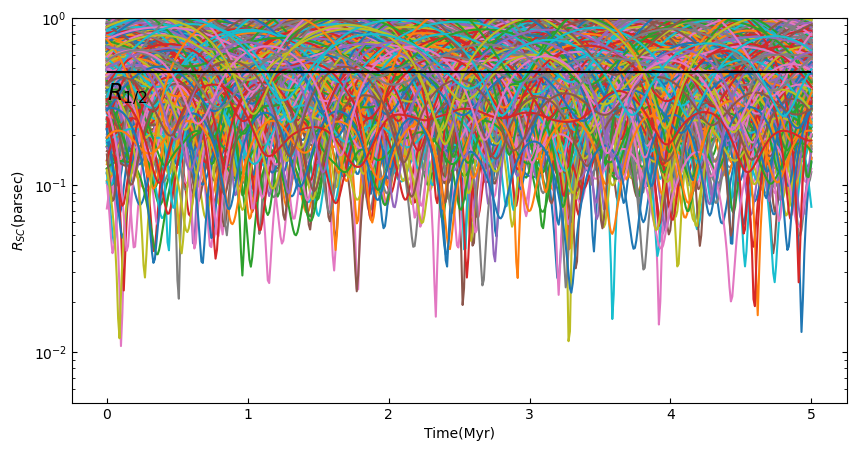

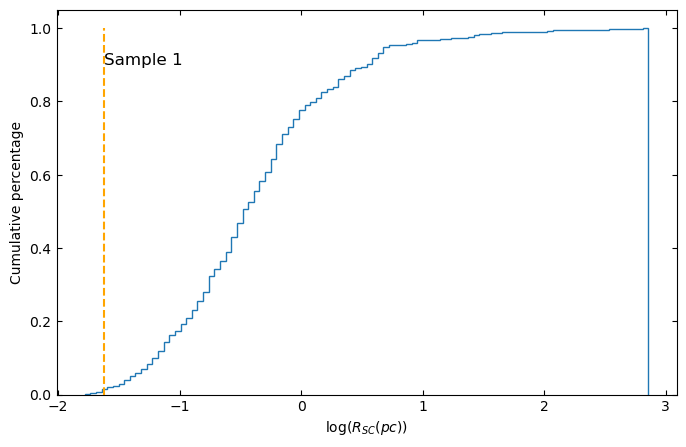

In [6]:
def get_r_sc(reshape_data, file_name:str = "", 
             clustering:bool =  False, cluster_factor:int = 10):
    k, j, _ = reshape_data.shape
    tot_data =  np.zeros((k,j))
    for i in range(k):
        x = reshape_data[i][:,0]
        y = reshape_data[i][:,1]
        z = reshape_data[i][:,2]
        tot_data[i] = np.sqrt(x**2 + y**2 + z**2)
    if clustering ==  True:
        res_data = tot_data.reshape((k//cluster_factor, 10, j))
        tot_data = np.average(res_data, axis=1)
    np.savetxt(file_name + "_Rsc_data.csv", tot_data, delimiter=",")
    return tot_data.T

avg_data = get_r_sc(reshape_data, str(choice), clustering=True)

one_pc  = 206265
time    = np.linspace(0, 5, 500)
avg_dis = np.zeros(500)

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
print("objects close to center of cluster")
for j in range(avg_data.shape[1]):
    avg_dis_to_center = np.average(avg_data[j]/one_pc)
    avg_dis[j] = avg_dis_to_center
    if avg_dis_to_center < 0.2:
        print(j)
    ax1.plot(time , avg_data[j]/one_pc)
ax1.set_ylim(0.5e-2, 1)

ax1.hlines(y = 1/1.7 * 0.8, xmax=5, xmin=0, color='black', zorder = 3)
ax1.text(0, 1/1.7*0.8 - 0.15, r"$R_{1/2}$", fontsize = 16)
ax1.set_yscale("log")
ax1.set_xlabel("Time(Myr)")
ax1.set_ylabel(r"$R_{SC}$(parsec)")
plt.show()
fig.savefig("R_sc_average.png")


fig1, ax2 = plt.subplots(1, 1, figsize=(8, 5))
n, bins, patches = ax2.hist(np.log(avg_dis), 100, density=True, histtype="step",
                            cumulative=True, label="Cumulative histogram")
ax2.vlines(x = np.log(avg_dis[choice]), ymax=1, ymin=0, linestyle ="--", color ="orange", zorder = 3)
ax2.text(np.log(avg_dis[choice]), 0.9, "Sample 1", fontsize = 12)
ax2.set_xlabel(r"log($R_{SC}(pc)$)")
ax2.set_ylabel("Cumulative percentage")
fig1.savefig("R_sc_hist.png")
plt.show()

## Part 2: Planetary System Simulation


The initial conditions are:

- 5 Jovian planets with same 1 Jupiter mass
- Wide system with the farthest one at ~200 AU
- Perturber star only added when <1000AU distance 


In [2]:
choice = 210

sim = rebound.Simulation()
# start the visualization server: in your browser go to http://localhost:3274
# sim.start_server(port=3274)
sim.G = 4*np.pi**2

close_system = np.array([1, 2.5, 6.3, 15.9, 39.7])
wide_system  = np.array([5.2, 13.04, 32.7, 82.2, 206.2])
# Star
sim.add(m=1.0, hash="host_star")
# 5 planets
for i, distance in enumerate(wide_system):
    sim.add(m=1e-3, a = distance, hash = f"p{i+1}")
sim.move_to_com()


end_time    = 5e6
planet_dt   = 100
N_data_pt   = int(5e4)
planet_time = np.linspace(0, end_time, N_data_pt)


arr_collection = []
for i in range(15):
    arr_collection.append(np.zeros(N_data_pt))

perturb_time, perturb_ind       = np.loadtxt(str(choice) + "_encounter.csv", delimiter=",", unpack=True)
perturb_x, perturb_y, perturb_z, perturb_vx, perturb_vy, perturb_vz = np.loadtxt(str(choice) + "_enc_pos.csv", delimiter=",", unpack=True)


trigger     = False
current_ind = 0
for i,t in enumerate(planet_time):
    if current_ind < len(perturb_x):
        if not trigger and t/1e6 > perturb_time[current_ind]:
            x0 = perturb_x[current_ind] + sim.particles["host_star"].x
            y0 = perturb_y[current_ind] + sim.particles["host_star"].y
            z0 = perturb_z[current_ind] + sim.particles["host_star"].z
            vx0 = perturb_vx[current_ind] + sim.particles["host_star"].vx
            vy0 = perturb_vy[current_ind] + sim.particles["host_star"].vy
            vz0 = perturb_vz[current_ind] + sim.particles["host_star"].vz
            sim.add(m=0.5, x=x0, y=y0, z=z0, vx=vx0, vy=vy0, vz=vz0, hash = "perturber")
            trigger     = True
            current_ind += 1
            print("perturber addeed at t=", t/1e6, "Myr")
    
    if trigger and t/1e6 > perturb_time[current_ind-1]+0.001:
        trigger = False
        sim.remove(hash="perturber")
        sim.move_to_com()
        print("perturber removed at t=", t/1e6, "Myr")


    sim.integrate(t)

    for j in range(5):
        orb_p = sim.particles[j+1].orbit(primary = sim.particles["host_star"])
        arr_collection[j][i]    = orb_p.a
        arr_collection[j+5][i]  = orb_p.e
        arr_collection[j+10][i] = orb_p.inc

perturber addeed at t= 0.9570191403828076 Myr
perturber removed at t= 0.9580191603832076 Myr
perturber addeed at t= 0.9581191623832477 Myr
perturber removed at t= 0.9590191803836077 Myr
perturber addeed at t= 0.9591191823836477 Myr
perturber removed at t= 0.9600192003840077 Myr
perturber addeed at t= 0.9601192023840477 Myr
perturber removed at t= 0.9610192203844077 Myr
perturber addeed at t= 1.9440388807776154 Myr
perturber removed at t= 1.9450389007780153 Myr
perturber addeed at t= 1.9451389027780555 Myr
perturber removed at t= 1.9460389207784154 Myr
perturber addeed at t= 1.9461389227784556 Myr
perturber removed at t= 1.9470389407788153 Myr
perturber addeed at t= 1.9471389427788555 Myr
perturber removed at t= 1.9480389607792155 Myr
perturber addeed at t= 1.9920398407968158 Myr
perturber removed at t= 1.9930398607972157 Myr
perturber addeed at t= 1.9931398627972559 Myr
perturber removed at t= 1.9940398807976158 Myr
perturber addeed at t= 2.53705074101482 Myr
perturber removed at t= 2.

### Part 2.1

Here is a plot of orbital element evolution of the planetary system in the N = 2000 cluster. (See the Fig.4 in the [publication](https://academic.oup.com/mnras/article/470/4/4337/3867314) mentioned above) The system has five planets initially, which are initially on circular and coplanar orbits. 

- In the top panel, the semimajor axis of each planet is plotted in coloured curved as a function of time (in log-scale), while the dotted grey curve indicates the distance from the host star to the cluster centre (axis on the right, $R_{sc}$ mentioned above)
- In the middle panel, the evolution of the eccentricity of each planet is plotted as a function of time, and the grey boxes (very thin but they have horizontal thickness) represent the time interval when a perturber star is added to pull the planets with it gravitational potential.
- At the bottom panel the inclination of each planet with respect to the initial orbital plane is plotted

In this particular case, the host star had several close encounter events with other stars in the cluster. The outer most planet (P5) was ejected from the system.

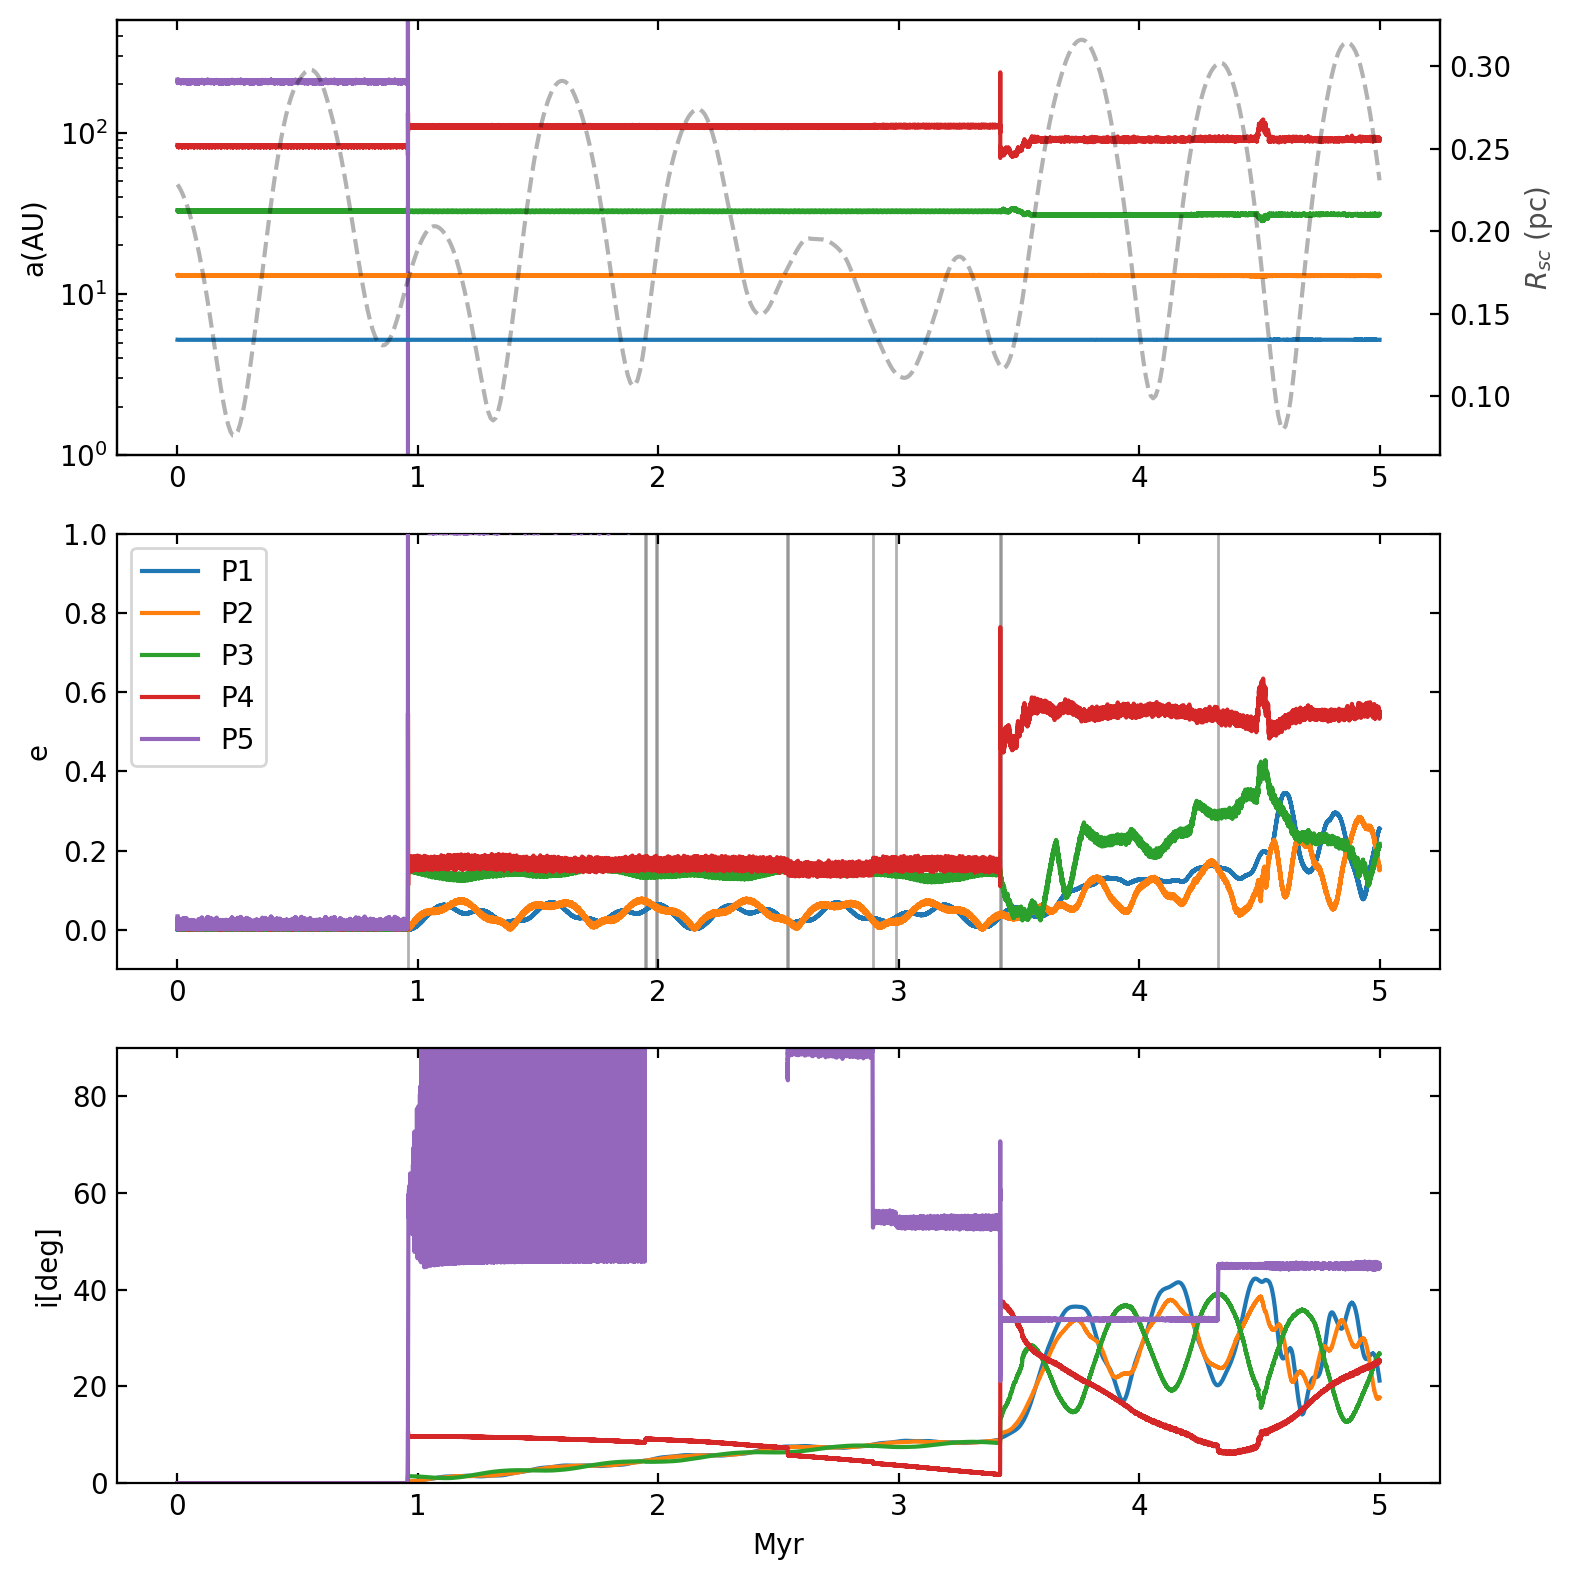

In [3]:
a_p1, a_p2, a_p3, a_p4, a_p5 = arr_collection[0:5]
e_p1, e_p2, e_p3, e_p4, e_p5 = arr_collection[5:10]
i_p1, i_p2, i_p3, i_p4, i_p5 = arr_collection[10:15]

R_sc_data = np.loadtxt(str(choice) + "_Rsc_data.csv", delimiter=",", usecols=choice)

one_pc  = 206265

fig3, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8))
ax1.plot(planet_time/1e6, a_p1, label = "P1", zorder = 3)
ax1.plot(planet_time/1e6, a_p2, label = "P2", zorder = 3)
ax1.plot(planet_time/1e6, a_p3, label = "P3", zorder = 2)
ax1.plot(planet_time/1e6, a_p4, label = "P4", zorder = 2)
ax1.plot(planet_time/1e6, a_p5, label = "P5", zorder = 2)

# Create secondary y-axis for Rsc
ax1_twin = ax1.twinx()
ax1_twin.plot(np.linspace(0, 5, len(R_sc_data)), R_sc_data/one_pc, color="black", linestyle = "--", alpha=0.3, zorder=1)
ax1_twin.set_ylabel(r"$R_{sc}$ (pc)", color='black', alpha = 0.7)
ax1_twin.tick_params(axis='y')

ax2.plot(planet_time/1e6, e_p1, zorder = 3, label = "P1")
ax2.plot(planet_time/1e6, e_p2, zorder = 3, label = "P2")
ax2.plot(planet_time/1e6, e_p3, zorder = 3, label = "P3")
ax2.plot(planet_time/1e6, e_p4, zorder = 3, label = "P4")
ax2.plot(planet_time/1e6, e_p5, zorder = 3, label = "P5")

indind  = [0, 4, 8, 10, 13, 16, 17, 21]
indind2 = [3, 7, 9, 12, 15, 16, 20, 23]
for j in range(len(indind)):
    x1 = perturb_time[indind[j]]
    x2 = perturb_time[indind2[j]]
    ax2.fill_betweenx((-0.1,1.1), (x1, x1), (x2,x2), color = "black", alpha = 0.3, zorder=1)

ax3.plot(planet_time/1e6, i_p1*180/np.pi)
ax3.plot(planet_time/1e6, i_p2*180/np.pi)
ax3.plot(planet_time/1e6, i_p3*180/np.pi)
ax3.plot(planet_time/1e6, i_p4*180/np.pi)
ax3.plot(planet_time/1e6, i_p5*180/np.pi)


ax1.set_ylim(1, 500)
ax1.set_yscale('log')
ax2.set_ylim(-0.1, 1.0)
ax1.set_ylabel("a(AU)")
ax2.set_ylabel("e")
ax3.set_ylim(0, 90)
ax3.set_ylabel('i[deg]')
ax3.set_xlabel("Myr")
ax2.legend(loc = 'best')
plt.tight_layout()
plt.show()
fig3.savefig("planet_sim_210.png",  bbox_inches='tight')